In [2]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error

In [3]:
# Loading the dataset
df = pd.read_csv('car_price.csv')
df.head()

,CarID,Brand,Model_Year,Fuel_Type,Transmission,Km_Driven,Mileage_kmpl,Engine_CC,Owners,Price_Lakhs
0,1,Honda,2016,Electric,Manual,19427,27.4,2530,0,16.62
1,2,Tata,2013,Petrol,Automatic,78566,15.5,2698,0,10.03
2,3,Maruti,2018,Petrol,Automatic,63850,25.0,873,3,22.22
3,4,Kia,2006,Petrol,Automatic,5482,19.1,2765,3,17.82
4,5,Kia,2019,CNG,Automatic,17940,10.3,1901,2,18.29


In [4]:
#EDA
print("Dataset Info : ")
print(df.info())
print("\nDataset Shape : ", df.shape)
print("\nDataset Description : ")
print(df.describe())
print("\nMissing Values : ")
print(df.isnull().sum())
print("\n Price Summary:")
print(df["Price_Lakhs"].describe())

Dataset Info : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   CarID         700 non-null    int64  
 1   Brand         700 non-null    object 
 2   Model_Year    700 non-null    int64  
 3   Fuel_Type     700 non-null    object 
 4   Transmission  700 non-null    object 
 5   Km_Driven     700 non-null    int64  
 6   Mileage_kmpl  700 non-null    float64
 7   Engine_CC     700 non-null    int64  
 8   Owners        700 non-null    int64  
 9   Price_Lakhs   700 non-null    float64
dtypes: float64(2), int64(5), object(3)
memory usage: 54.8+ KB
None

Dataset Shape :  (700, 10)

Dataset Description : 
           CarID   Model_Year      Km_Driven  Mileage_kmpl    Engine_CC  \
count  700.00000   700.000000     700.000000    700.000000   700.000000   
mean   350.50000  2014.260000  103419.057143     19.108143  1915.311429   
std    202.21688  

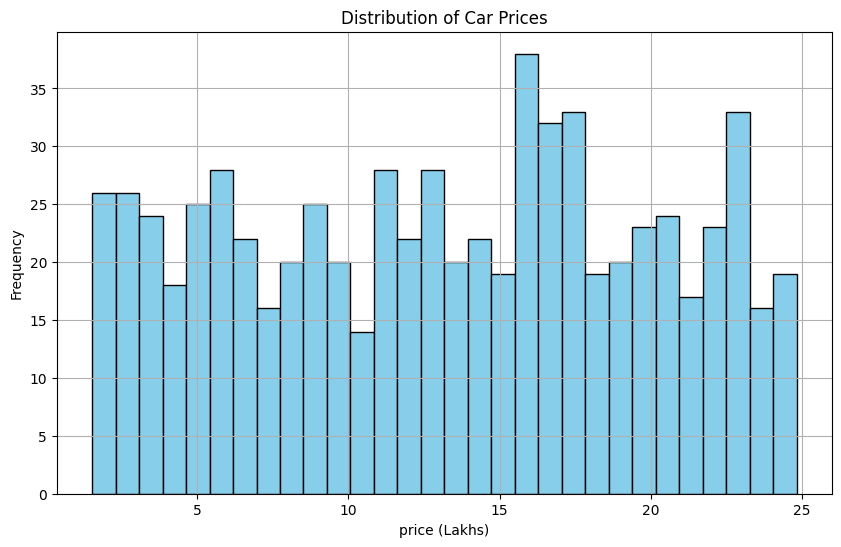

In [5]:
# Visualization
plt.figure(figsize=(10,6))
df['Price_Lakhs'].hist(bins=30,color='skyblue', edgecolor='black')
plt.title('Distribution of Car Prices')
plt.xlabel('price (Lakhs)')
plt.ylabel('Frequency')
plt.show()

In [6]:
# Encode Categorical Variables

encoder = LabelEncoder()
df['Brand'] = encoder.fit_transform(df['Brand'])
df['Fuel_Type'] = encoder.fit_transform(df['Fuel_Type'])
df['Transmission'] = encoder.fit_transform(df['Transmission'])

In [7]:
df.head()

,CarID,Brand,Model_Year,Fuel_Type,Transmission,Km_Driven,Mileage_kmpl,Engine_CC,Owners,Price_Lakhs
0,1,0,2016,2,1,19427,27.4,2530,0,16.62
1,2,5,2013,3,0,78566,15.5,2698,0,10.03
2,3,4,2018,3,0,63850,25.0,873,3,22.22
3,4,2,2006,3,0,5482,19.1,2765,3,17.82
4,5,2,2019,0,0,17940,10.3,1901,2,18.29


In [8]:
# Feature Target Split
X = df.drop(["CarID", "Price_Lakhs"], axis=1)
y = df["Price_Lakhs"]

In [9]:
# train test split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
# Hyperparameter Tuning
print("\n Starting Hyperparameter Tuning...")

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(x_train, y_train)

print("\n Best Parameters:")
print(grid.best_params_)


 Starting Hyperparameter Tuning...

 Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


In [11]:
# train best model
best_model = grid.best_estimator_

best_model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [12]:
# Evaluation
y_pred = best_model.predict(x_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("\n Model Performance:")
print("R2 Score:", r2)
print("MAE:", mae)


 Model Performance:
R2 Score: -0.014096957542496513
MAE: 5.819337945527064


In [13]:
#Save the model

model_package = {
    "model": best_model,
    "encoder": encoder,
    "features": X.columns.tolist()
}

with open("car_price_complete_model.pkl", "wb") as f:
    pickle.dump(model_package, f)

print("\n Single PKL File Saved: car_price_complete_model.pkl")


 Single PKL File Saved: car_price_complete_model.pkl
